In [1]:
import pandas as pd
#import geopandas as gpd
#import matplotlib.pyplot as plt
#import contextily as ctx
from shapely.geometry import Point, box, Polygon
import numpy as np
from matplotlib_scalebar.scalebar import ScaleBar
#from pyproj import Transformer
import cv2

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geopandas as gpd
import matplotlib.pyplot as plt
from pyproj import Transformer

In [2]:
color_df = pd.read_csv('../datasets/geo_med.csv')
color_df

,image_idx,hex,rgb,hsl,lab,gbifID,identifier,latitude,longitude
0,0,#d4b4e2,"(212, 180, 226)","(0.782608695652174, 0.44230769230769224, 0.796...","(197, 148, 109)",923911394,https://inaturalist-open-data.s3.amazonaws.com...,48.826305,-102.092171
1,2,#cdb3cd,"(205, 179, 205)","(0.8333333333333334, 0.2063492063492065, 0.752...","(193, 142, 118)",923910407,https://inaturalist-open-data.s3.amazonaws.com...,43.613086,-73.057076
2,4,#bda5d7,"(189, 165, 215)","(0.7466666666666667, 0.3846153846153846, 0.745...","(182, 146, 106)",899970365,https://inaturalist-open-data.s3.amazonaws.com...,43.066871,-87.890565
3,7,#9984ae,"(153, 132, 174)","(0.75, 0.2058823529411765, 0.6000000000000001)","(149, 144, 109)",891778924,https://inaturalist-open-data.s3.amazonaws.com...,42.140556,-87.831643
4,9,#ba9fdd,"(186, 159, 221)","(0.739247311827957, 0.476923076923077, 0.74509...","(178, 150, 100)",891760719,https://inaturalist-open-data.s3.amazonaws.com...,38.679240,-97.990035
...,...,...,...,...,...,...,...,...,...
20623,41059,#a191c2,"(161, 145, 194)","(0.7210884353741497, 0.2865497076023391, 0.664...","(161, 144, 105)",1024218211,https://inaturalist-open-data.s3.amazonaws.com...,41.569419,-88.150552
20624,41060,#b77fb7,"(183, 127, 183)","(0.8333333333333334, 0.28, 0.607843137254902)","(154, 159, 107)",1024202810,https://inaturalist-open-data.s3.amazonaws.com...,45.057871,-87.168277
20625,41061,#af96cb,"(175, 150, 203)","(0.7452830188679246, 0.3375796178343948, 0.692...","(168, 148, 104)",1024200169,https://inaturalist-open-data.s3.amazonaws.com...,42.921738,-88.026752
20626,41063,#c5b9b2,"(197, 185, 178)","(0.06140350877192979, 0.1407407407407409, 0.73...","(194, 131, 133)",1024198670,https://inaturalist-open-data.s3.amazonaws.com...,40.791723,-80.492498


### If multiple rows with the same gbifID (because of multiple pictures for one observation), choose a random one

In [3]:
color_df_reduced = (
    color_df.groupby("gbifID", sort=False, group_keys=False)
    .apply(lambda x: x.sample(1,random_state=123))
    .reset_index(drop=True)
)
color_df_reduced

/var/folders/qh/c7rwx84921n2kznn09zb2pnh0000gn/T/ipykernel_6721/1712891894.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(1,random_state=123))


,image_idx,hex,rgb,hsl,lab,gbifID,identifier,latitude,longitude
0,0,#d4b4e2,"(212, 180, 226)","(0.782608695652174, 0.44230769230769224, 0.796...","(197, 148, 109)",923911394,https://inaturalist-open-data.s3.amazonaws.com...,48.826305,-102.092171
1,2,#cdb3cd,"(205, 179, 205)","(0.8333333333333334, 0.2063492063492065, 0.752...","(193, 142, 118)",923910407,https://inaturalist-open-data.s3.amazonaws.com...,43.613086,-73.057076
2,4,#bda5d7,"(189, 165, 215)","(0.7466666666666667, 0.3846153846153846, 0.745...","(182, 146, 106)",899970365,https://inaturalist-open-data.s3.amazonaws.com...,43.066871,-87.890565
3,7,#9984ae,"(153, 132, 174)","(0.75, 0.2058823529411765, 0.6000000000000001)","(149, 144, 109)",891778924,https://inaturalist-open-data.s3.amazonaws.com...,42.140556,-87.831643
4,9,#ba9fdd,"(186, 159, 221)","(0.739247311827957, 0.476923076923077, 0.74509...","(178, 150, 100)",891760719,https://inaturalist-open-data.s3.amazonaws.com...,38.679240,-97.990035
...,...,...,...,...,...,...,...,...,...
16582,41059,#a191c2,"(161, 145, 194)","(0.7210884353741497, 0.2865497076023391, 0.664...","(161, 144, 105)",1024218211,https://inaturalist-open-data.s3.amazonaws.com...,41.569419,-88.150552
16583,41060,#b77fb7,"(183, 127, 183)","(0.8333333333333334, 0.28, 0.607843137254902)","(154, 159, 107)",1024202810,https://inaturalist-open-data.s3.amazonaws.com...,45.057871,-87.168277
16584,41061,#af96cb,"(175, 150, 203)","(0.7452830188679246, 0.3375796178343948, 0.692...","(168, 148, 104)",1024200169,https://inaturalist-open-data.s3.amazonaws.com...,42.921738,-88.026752
16585,41063,#c5b9b2,"(197, 185, 178)","(0.06140350877192979, 0.1407407407407409, 0.73...","(194, 131, 133)",1024198670,https://inaturalist-open-data.s3.amazonaws.com...,40.791723,-80.492498


# Plot the averaged grid cells

#### a bunch of helper functions that we will string together

In [4]:
# color conversion functions
def lab_to_rgb(lab):
    """convert (L,a,b) in OpenCV's Lab to (r,g,b) in [0,255]"""
    arr = np.array([[lab]], dtype=np.uint8) # basically makes a single-pixel image
    rgb = cv2.cvtColor(arr, cv2.COLOR_LAB2RGB)[0][0]
    return tuple(int(x) for x in rgb)

def rgb_to_hex(rgb):
    # rgb should be a tuple like (R, G, B)
    return '#{:02x}{:02x}{:02x}'.format(*rgb)
##########

# start by making a geodataframe from our df
def create_gdf(df):
    geometry = [Point(xy) for xy in zip(df['longitude'], df['latitude'])]
    gdf = gpd.GeoDataFrame(df, geometry=geometry, crs="EPSG:4326").to_crs(epsg=3857)
    return gdf

# define a grid with cell size in m, we want EPSG:3857
def create_square_grid(min_lon, min_lat, max_lon, max_lat, cell_size=200000): # 200km
    bbox = box(min_lon, min_lat, max_lon, max_lat)
    bbox_gdf = gpd.GeoDataFrame({'geometry': [bbox]}, crs="EPSG:4326").to_crs(epsg=3857)
    xmin, ymin, xmax, ymax = bbox_gdf.total_bounds
    polygons = []
    for x in np.arange(xmin, xmax, cell_size):
        for y in np.arange(ymin, ymax, cell_size):
            polygons.append(Polygon([(x, y), (x+cell_size, y), (x+cell_size, y+cell_size), (x, y+cell_size)]))
    grid_gdf = gpd.GeoDataFrame({'geometry': polygons}, crs="EPSG:3857")
    return grid_gdf

# the lab codes in the df are in strings.... let's convert 
# them to np arrays of integers
def parse_lab(lab):
    if isinstance(lab, str):
        lab = lab.strip('()').split(',')
        return np.array([int(x) for x in lab])
    elif isinstance(lab, tuple):
        return np.array(lab)
    else:
        return np.array([np.nan, np.nan, np.nan])

def average_colors_in_grid(gdf_points, grid_gdf):
    joined = gpd.sjoin(gdf_points, grid_gdf, how='left', predicate='within')

    # the csv reads the lab vals in as strings.... so this helps parse
    joined['lab_numeric'] = joined['lab'].apply(parse_lab) 

    # now average 
    grouped = joined.groupby('index_right')['lab_numeric'].apply(
        lambda labs: np.nanmean(np.stack(labs), axis=0)
    ).reset_index()

    grouped['avg_hex'] = grouped['lab_numeric'].apply(
        lambda lab: rgb_to_hex(lab_to_rgb(np.round(lab).astype(np.uint8)))
    )

    grid_gdf['avg_hex'] = grouped.set_index('index_right')['avg_hex']
    return grid_gdf

#### finally, make the map

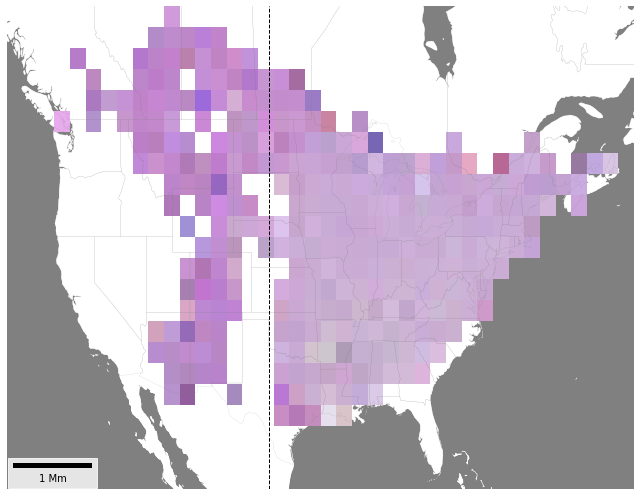

In [5]:
gdf = create_gdf(color_df_reduced)

min_lon, min_lat, max_lon, max_lat = -130, 24, -59, 54
grid = create_square_grid(min_lon, min_lat, max_lon, max_lat)
grid_with_color = average_colors_in_grid(gdf, grid)

grid_with_data = grid_with_color.dropna(subset=['avg_hex'])

# cartopy wants us back in lat / lon...
grid_ll = grid_with_data.to_crs(epsg=4326)

# specify a mercator map
fig = plt.figure(figsize=(12,7))
ax = plt.axes(projection=ccrs.Mercator()) # this is epsg3857 = web-mercator, so we can get a scalebar in m
xmin, ymin, xmax, ymax = grid.to_crs(epsg=4326).total_bounds
#ax.set_xlim(xmin, xmax)
#ax.set_ylim(ymin, ymax)
ax.set_extent([xmin, xmax, ymin, ymax], crs=ccrs.PlateCarree()) 
#ax.set_extent([-130, -59, 24, 54], crs=ccrs.PlateCarree()) 

# add ocean and land 
# more here: https://scitools.org.uk/cartopy/docs/latest/matplotlib/feature_interface.html
ax.add_feature(cfeature.OCEAN, facecolor="grey")
ax.add_feature(cfeature.LAND,  facecolor="white")

# plot our grid on top
grid_ll.plot(
    ax=ax,
    facecolor=grid_ll["avg_hex"],
    edgecolor="none",
    transform=ccrs.PlateCarree()
)

# put state boundaries on top
ax.add_feature(cfeature.STATES, edgecolor="gray", linewidth=0.1)

# add our vertical line to separate sides
ax.plot(
    [-100, -100], [ymin, ymax],
    color="black", linestyle="--", linewidth=1,
    transform=ccrs.PlateCarree()
)

ax.axis("off")

scalebar = ScaleBar(dx=1, 
                    units="m", 
                    location='lower left', 
                    pad=0.5, 
                    color='black', 
                    box_color='white', 
                    box_alpha=0.8, 
                    length_fraction=0.2,
                    rotation='horizontal-only')
ax.add_artist(scalebar)

plt.tight_layout()
plt.savefig("../figures/figures_current/components/figure_2a.pdf")
plt.show()

In [6]:
xmin, ymin, xmax, ymax

(np.float64(-129.99999999999997),
 np.float64(24.000000000000004),
 np.float64(-58.134777270438285),
 np.float64(54.95639625203041))